In [1]:
import numpy as np
from sklearn.datasets import make_moons
import seaborn as sns
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Dropout, Conv2D, Flatten, MaxPooling2D
from keras.optimizers import Adam

In [ ]:
train_data = tf.keras.preprocessing.image_dataset_from_directory(
    directory="..\\..\\..\\cnn\\train",      # Path to the training data directory
    labels="inferred",                      # Infer labels from subdirectory names
    label_mode="int",                       # Labels are returned as integers
    batch_size=32,                          # Number of images per batch
    image_size=(256, 256),                  # Resize images to 256x256 pixels
)

Found 20000 files belonging to 2 classes.


In [3]:
test_data = tf.keras.utils.image_dataset_from_directory(
    directory="..\\..\\..\\cnn\\test",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(256, 256),
)

Found 5000 files belonging to 2 classes.


In [4]:

# normalize the data so that the pixel values are between 0 and 1
def normalize(image, label):
    """
    Normalizes image pixel values to the range [0, 1].

    Args:
        image: A tensor representing the image, with pixel values in the range [0, 255].
        label: The corresponding label for the image.

    Returns:
        A tuple of (normalized_image, label), where normalized_image has pixel values in the range [0, 1].
    """
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

In [5]:
train_data = train_data.map(normalize)
test_data = test_data.map(normalize)

### Define CNN Model

In [6]:
model = Sequential()
model.add(Conv2D(filters=32, kernel_size=(3, 3),
          activation='relu', input_shape=(256, 256, 3)))
model.add(MaxPooling2D(pool_size=(2, 2), strides=2))

model.add(Conv2D(filters=64, kernel_size=(3, 3),
          activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2), strides=2))

model.add(Conv2D(filters=128, kernel_size=(3, 3),
          activation='relu',))
model.add(MaxPooling2D(pool_size=(2, 2), strides=2))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [7]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 254, 254, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 127, 127, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 125, 125, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 62, 62, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 60, 60, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 30, 30, 128)      0

In [8]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [9]:
history = model.fit(train_data, 
                    epochs=10, 
                    validation_data=test_data,
                    verbose=1,
                    use_multiprocessing=True,
                    workers=6)

Epoch 1/10
625/625 [==============================] - 88s 124ms/step - loss: 0.6314 - accuracy: 0.6368 - val_loss: 0.5605 - val_accuracy: 0.6992
Epoch 2/10
625/625 [==============================] - 66s 105ms/step - loss: 0.4896 - accuracy: 0.7603 - val_loss: 0.4570 - val_accuracy: 0.7912
Epoch 3/10
625/625 [==============================] - 65s 103ms/step - loss: 0.3741 - accuracy: 0.8302 - val_loss: 0.5348 - val_accuracy: 0.7838
Epoch 4/10
625/625 [==============================] - 65s 104ms/step - loss: 0.2412 - accuracy: 0.8994 - val_loss: 0.6625 - val_accuracy: 0.7706
Epoch 5/10
625/625 [==============================] - 64s 102ms/step - loss: 0.1333 - accuracy: 0.9481 - val_loss: 0.8338 - val_accuracy: 0.7932
Epoch 6/10
625/625 [==============================] - 64s 103ms/step - loss: 0.0837 - accuracy: 0.9692 - val_loss: 1.0678 - val_accuracy: 0.7896
Epoch 7/10
625/625 [==============================] - 65s 104ms/step - loss: 0.0601 - accuracy: 0.9798 - val_loss: 1.1232 - val_ac

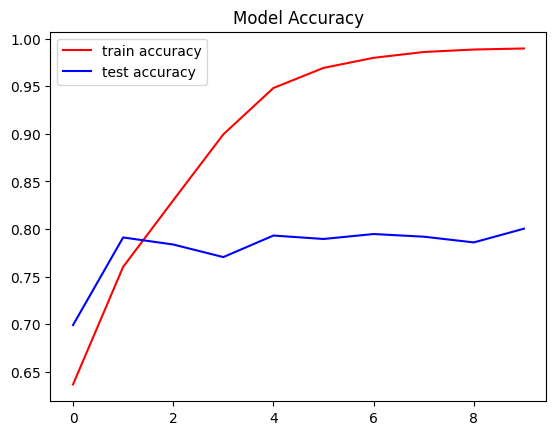

In [10]:
plt.plot(history.history['accuracy'],color='red', label='train accuracy')
plt.plot(history.history['val_accuracy'],color='blue', label='test accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.show()